### aBeta WSI Quantification & Analysis Pipeline
**Paper**: *Quantifying Amyloid-Beta in Alzheimer's Disease Correlates with Cognitive Testing and Age of Death*

This notebook runs the full analysis pipeline:
1. **Setup** — resolve SVS paths from patient manifests
2. **Single-slide test** — verify PPC pipeline on one slide
3. **Batch processing** — process all AD + TDP patient slides
4. **Aggregate metrics** — per-patient aBeta burden scores
5. **Figure 4** — correlate aBeta burden with neuropath scores + clinical outcomes
6. **Figure 5** — update clustering with quantification features
7. **Cross-group comparison** — AD vs TDP vs controls
8. **Save outputs** — Excel + H5 results

In [29]:
# ── Cell 1: Environment setup ──────────────────────────────────────────────
import sys, os

sys.path.insert(0, "/nashome/bhavesh/ABeta/aBeta-WSI-Analysi-Pipeline")
import json
import glob
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
from scipy import stats
from scipy.stats import spearmanr, kruskal, mannwhitneyu
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Pipeline imports
from WSU.ppc.ppc_processing import ppc_process_wsi

# Paths
WORK_DIR = Path("/nashome/bhavesh/ABeta/aBeta-WSI-Analysi-Pipeline")
APOLLO_ROOT = Path("/wsi_archive/APOLLO_NP")
OUTPUT_DIR = WORK_DIR / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Working dir : {WORK_DIR}")
print(f"PPC output  : {OUTPUT_DIR}")
print(f"WSI archive : {APOLLO_ROOT}")
print(f"Python      : {sys.version.split()[0]}")

Working dir : /nashome/bhavesh/ABeta/aBeta-WSI-Analysi-Pipeline
PPC output  : /nashome/bhavesh/ABeta/aBeta-WSI-Analysi-Pipeline/output
WSI archive : /wsi_archive/APOLLO_NP
Python      : 3.12.12


### 1. SVS Paths from Patient Manifests

In [30]:
# ── Cell 2: Load patient manifests and resolve full SVS paths ──────────────
with open(WORK_DIR / "abeta_patients.json") as f:
    raw_ab = json.load(f)
with open(WORK_DIR / "tdp_patients.json") as f:
    raw_tdp = json.load(f)

# De-nest correctly for each groupt
AD_PATIENTS = raw_ab["ad"]["ad"]  # Alzheimer's Disease
ALS_PATIENTS = raw_tdp["als"]["als"]  # Amyotrophic Lateral Sclerosis

# ftld_tdp has sub-types: unknown / type_a-e  → flatten all, keep subtype label
FTLD_PATIENTS = {}
FTLD_SUBTYPE = {}
for subtype, pts in raw_tdp["ftld_tdp"].items():
    for pid, rmap in pts.items():
        FTLD_PATIENTS[pid] = rmap
        FTLD_SUBTYPE[pid] = subtype

# late_nc has stages 1/2/3 → flatten all, keep stage label
LATE_PATIENTS = {}
LATE_STAGE = {}
for stage, pts in raw_tdp["late_nc"].items():
    for pid, rmap in pts.items():
        LATE_PATIENTS[pid] = rmap
        LATE_STAGE[pid] = stage

print(f"AD patients       : {len(AD_PATIENTS)}")
print(f"ALS patients      : {len(ALS_PATIENTS)}")
print(
    f"FTLD-TDP patients : {len(FTLD_PATIENTS)}  subtypes={sorted(set(FTLD_SUBTYPE.values()))}"
)
print(
    f"LATE-NC patients  : {len(LATE_PATIENTS)}  stages={sorted(set(LATE_STAGE.values()))}"
)


def find_svs(patient_id: str, filename: str) -> str | None:
    """Locate SVS file in APOLLO_NP archive across all year directories."""
    if not filename:
        return None
    # Extract year prefix from patient ID (e.g. E20-138 -> 2020)
    try:
        yr_2digit = int(patient_id.split("-")[0].lstrip("EAO"))
        year_str = f"20{yr_2digit:02d}" if yr_2digit < 100 else str(yr_2digit)
        year_dirs = [APOLLO_ROOT / year_str]
    except (ValueError, IndexError):
        year_dirs = []
    # Always fall back to exhaustive scan of all years
    year_dirs += sorted(APOLLO_ROOT.glob("20??"))

    seen = set()
    for ydir in year_dirs:
        if str(ydir) in seen:
            continue
        seen.add(str(ydir))
        case_dir = ydir / patient_id
        if not case_dir.exists():
            continue
        for sub in ["Scanned Images", "scanned images", "Scanned_Images", ""]:
            p = case_dir / sub / filename if sub else case_dir / filename
            if p.is_file():
                return str(p)
    return None


# Build the slide manifest DataFrame
rows = []
for group, pts_dict, extra_map, extra_col in [
    ("AD", AD_PATIENTS, {}, None),
    ("ALS", ALS_PATIENTS, {}, None),
    ("FTLD-TDP", FTLD_PATIENTS, FTLD_SUBTYPE, "ftld_subtype"),
    ("LATE-NC", LATE_PATIENTS, LATE_STAGE, "late_stage"),
]:
    for pid, rmap in pts_dict.items():
        for region, fname in rmap.items():
            if region == "control":
                continue  # skip positive-control slides
            path = find_svs(pid, fname) if fname else None
            row = {
                "patient_id": pid,
                "group": group,
                "region": region,
                "filename": fname,
                "svs_path": path,
                "found": path is not None,
            }
            if extra_col:
                row[extra_col] = extra_map.get(pid, "")
            rows.append(row)

manifest = pd.DataFrame(rows)
manifest["h5_path"] = manifest["svs_path"].apply(
    lambda p: (
        str(OUTPUT_DIR / (Path(str(p)).stem + ".h5")) if pd.notna(p) and p else None
    )
)

print(f"\nTotal slides in manifest : {len(manifest)}")
print(f"  SVS files found        : {manifest.found.sum()}")
print(f"  SVS files missing      : {(~manifest.found).sum()}")
print()
print(manifest.groupby(["group", "found"]).size().unstack(fill_value=0))

AD patients       : 95
ALS patients      : 4
FTLD-TDP patients : 8  subtypes=['type_b', 'type_c', 'unknown']
LATE-NC patients  : 9  stages=['stage_1', 'stage_2', 'stage_3']

Total slides in manifest : 189
  SVS files found        : 103
  SVS files missing      : 86

found     False  True 
group                 
AD           33     62
ALS           5     15
FTLD-TDP     21     26
LATE-NC      27      0


In [31]:
# ── Cell 3: Show manifest preview ─────────────────────────────────────────
manifest[manifest.found].head(10)

,patient_id,group,region,filename,svs_path,found,ftld_subtype,late_stage,h5_path
0,E04-89,AD,hippocampus,E04-89_ABETA_1A.svs,/wsi_archive/APOLLO_NP/2004/E04-89/E04-89_ABET...,True,NaN,NaN,/nashome/bhavesh/ABeta/aBeta-WSI-Analysi-Pipel...
1,E06-184,AD,hippocampus,E06-184_ABETA_1A.svs,/wsi_archive/APOLLO_NP/2006/E06-184/E06-184_AB...,True,NaN,NaN,/nashome/bhavesh/ABeta/aBeta-WSI-Analysi-Pipel...
2,E06-187,AD,hippocampus,E06-187_ABETA_1A.svs,/wsi_archive/APOLLO_NP/2006/E06-187/E06-187_AB...,True,NaN,NaN,/nashome/bhavesh/ABeta/aBeta-WSI-Analysi-Pipel...
3,E10-149,AD,hippocampus,E10-149_ABETA_1B.svs,/wsi_archive/APOLLO_NP/2010/E10-149/scanned im...,True,NaN,NaN,/nashome/bhavesh/ABeta/aBeta-WSI-Analysi-Pipel...
4,E14-104,AD,frontal,E14-104_ABETA_1.svs,/wsi_archive/APOLLO_NP/2014/E14-104/scanned im...,True,NaN,NaN,/nashome/bhavesh/ABeta/aBeta-WSI-Analysi-Pipel...
5,E14-115,AD,hippocampus,E14-115_ABETA_1.svs,/wsi_archive/APOLLO_NP/2014/E14-115/scanned im...,True,NaN,NaN,/nashome/bhavesh/ABeta/aBeta-WSI-Analysi-Pipel...
6,E14-12,AD,hippocampus,E14-12_ABETA_1.svs,/wsi_archive/APOLLO_NP/2014/E14-12/scanned ima...,True,NaN,NaN,/nashome/bhavesh/ABeta/aBeta-WSI-Analysi-Pipel...
7,E14-134,AD,hippocampus,E14-134_ABETA_1.svs,/wsi_archive/APOLLO_NP/2014/E14-134/scanned im...,True,NaN,NaN,/nashome/bhavesh/ABeta/aBeta-WSI-Analysi-Pipel...
8,E14-14,AD,hippocampus,E14-14_ABETA_1.svs,/wsi_archive/APOLLO_NP/2014/E14-14/scanned ima...,True,NaN,NaN,/nashome/bhavesh/ABeta/aBeta-WSI-Analysi-Pipel...
9,E14-161,AD,hippocampus,E14-161_ABETA_1.svs,/wsi_archive/APOLLO_NP/2014/E14-161/scanned im...,True,NaN,NaN,/nashome/bhavesh/ABeta/aBeta-WSI-Analysi-Pipel...


### 2. Single-Slide Test — Verify PPC Pipeline

In [32]:
# ── Cell 4: Test PPC on one AD slide ──────────────────────────────────────
# Pick the first found AD slide for a quick sanity check
test_row = manifest[(manifest.group == "AD") & manifest.found].iloc[0]
print(f"Test slide  : {test_row.patient_id} / {test_row.region}")
print(f"SVS path    : {test_row.svs_path}")
print(f"H5 output   : {test_row.h5_path}")
print()

# WSU/ppc/ppc_processing.py

h5_path = ppc_process_wsi(
    wsi_path=test_row.svs_path,
    output_dir=str(OUTPUT_DIR),
    force_reprocess=True,
)
print(f"\nH5 saved to: {h5_path}")

Test slide  : E04-89 / hippocampus
SVS path    : /wsi_archive/APOLLO_NP/2004/E04-89/E04-89_ABETA_1A.svs
H5 output   : /nashome/bhavesh/ABeta/aBeta-WSI-Analysi-Pipeline/output/E04-89_ABETA_1A.h5


PPC WSI Processing  —  E04-89_ABETA_1A.svs

Step 1: Opening WSI …


  57768×40888 px   MPP=0.502 µm/px

Step 2: Auto-detecting stain hue …
  hue_value=0.0200  hue_width=0.2087

Step 3: Selecting processing level …
  Level 2: 3610×2555 px   MPP=8.0 µm/px

Step 4: Reading image …
  shape=(2555, 3610, 3)

Step 5: Running PPCModel detection …
  Device: cuda (NVIDIA RTX A5000)
  area_threshold=10 px   ws_min_dist=3 px
  9214081 raw instances found

Step 6: Extracting features …
  ✓ 5,500 instances after area filter
  area  : mean=2162 µm²  p50=1487  range=[646, 42079]
  elong : mean=0.604  ecc mean=0.759

Step 7: Saving → /nashome/bhavesh/ABeta/aBeta-WSI-Analysi-Pipeline/output/E04-89_ABETA_1A.h5
  ✓ Saved

Done!  5,500 amyloid instances  →  /nashome/bhavesh/ABeta/aBeta-WSI-Analysi-Pipeline/output/E04-89_ABETA_1A.h5


H5 saved to: /nashome/bhavesh/ABeta/aBeta-WSI-Analysi-Pipeline/output/E04-89_ABETA_1A.h5


H5 datasets: ['area', 'centroid_x', 'centroid_y', 'eccentricity', 'elongation', 'major_axis', 'minor_axis', 'orientation']
Attributes : {'ds': np.float64(16.00267359097094), 'mpp_proc': np.float64(8.039743212103799), 'mpp_x': np.float64(0.5024), 'n_instances': np.int64(5500), 'proc_level': np.int64(2), 'slide_H': np.int64(40888), 'slide_W': np.int64(57768), 'wsi_path': '/wsi_archive/APOLLO_NP/2004/E04-89/E04-89_ABETA_1A.svs'}

Instances detected : 5,500
Area (µm²)  mean   : 2162.5
Area (µm²)  median : 1486.7
Area (µm²)  range  : [646, 42079]


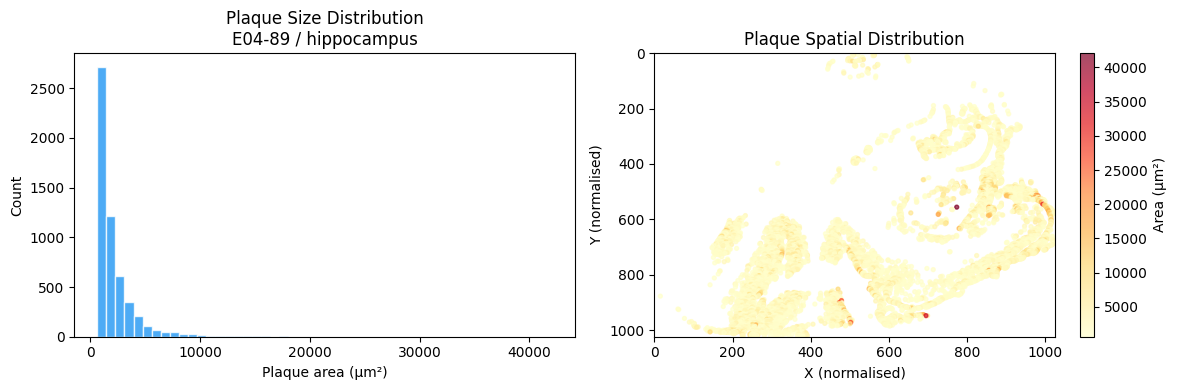

In [37]:
# ── Cell 5: Inspect H5 output from test slide ──────────────────────────────

with h5py.File(test_row.h5_path, "r") as f:
    print("H5 datasets:", list(f.keys()))
    print("Attributes :", dict(f.attrs))
    n = f.attrs.get("n_instances", 0)
    area = f["area"][:] if "area" in f else np.array([])

print(f"\nInstances detected : {int(n):,}")
if len(area):
    print(f"Area (µm²)  mean   : {area.mean():.1f}")
    print(f"Area (µm²)  median : {np.median(area):.1f}")
    print(f"Area (µm²)  range  : [{area.min():.0f}, {area.max():.0f}]")

# Quick distribution plot
if len(area) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(area, bins=50, color="#2196F3", edgecolor="white", alpha=0.8)
    axes[0].set_xlabel("Plaque area (µm²)")
    axes[0].set_ylabel("Count")
    axes[0].set_title(
        f"Plaque Size Distribution\n{test_row.patient_id} / {test_row.region}"
    )

    with h5py.File(test_row.h5_path, "r") as f:
        cx = f["centroid_x"][:] if "centroid_x" in f else None
        cy = f["centroid_y"][:] if "centroid_y" in f else None
    if cx is not None and cy is not None:
        sc = axes[1].scatter(cx, cy, c=area, cmap="YlOrRd", s=8, alpha=0.7)
        plt.colorbar(sc, ax=axes[1], label="Area (µm²)")
        axes[1].set_xlim(0, 1024)
        axes[1].set_ylim(1024, 0)
        axes[1].set_title("Plaque Spatial Distribution")
        axes[1].set_xlabel("X (normalised)")
        axes[1].set_ylabel("Y (normalised)")

    plt.tight_layout()
    plt.savefig(str(OUTPUT_DIR / "test_slide_distribution.png"), dpi=120)
    plt.show()

Slide area: 9.54e+09 µm²
Bin area: 9.32e+06 µm²
Max normalised signal: 1.2763
Mean normalised signal: 0.0012


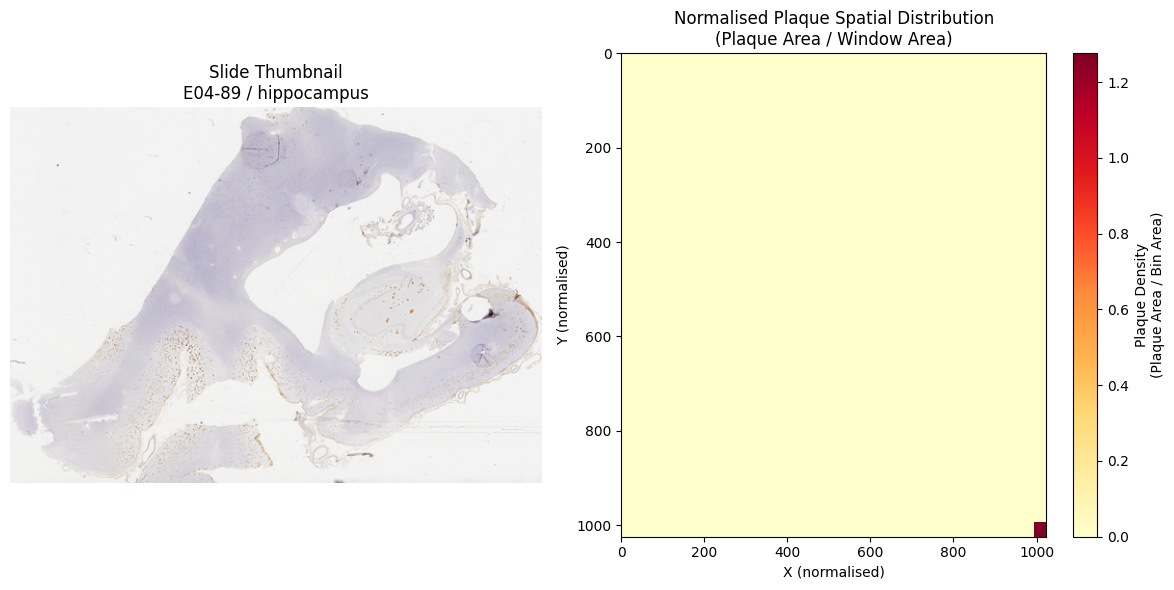

In [39]:
# Cell 5.1 Show slide thumbnail next to normalized plaque spatial distribution heatmap

import openslide

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
# Left: Slide thumbnail
sl = openslide.OpenSlide(test_row.svs_path)
thumb = sl.get_thumbnail((512, 512))
axes[0].imshow(thumb)
axes[0].set_title(f"Slide Thumbnail\n{test_row.patient_id} / {test_row.region}")
axes[0].axis("off")

# Right: Normalized plaque spatial distribution heatmap
# Signal = plaque area per bin / physical area of that bin (gives dimensionless local density)
with h5py.File(test_row.h5_path, "r") as f:
    cx = f["centroid_x"][:] if "centroid_x" in f else None
    cy = f["centroid_y"][:] if "centroid_y" in f else None
    area = f["area"][:] if "area" in f else None
    tissue_area_um2 = float(f.attrs.get("tissue_area_um2", 0))
    # Always read slide geometry for accurate bin-area calculation
    proc_level = int(f.attrs.get("proc_level", 2))
    slide_W = float(f.attrs.get("slide_W", 0))
    slide_H = float(f.attrs.get("slide_H", 0))
    mpp_proc = float(f.attrs.get("mpp_proc", 1.0))

# Compute slide area from geometry; fall back to tissue area if dims unavailable
if slide_W > 0 and slide_H > 0 and mpp_proc > 0:
    downsample = 2 ** proc_level
    proc_W = slide_W / downsample
    proc_H = slide_H / downsample
    slide_area_um2 = proc_W * proc_H * (mpp_proc ** 2)
elif tissue_area_um2 > 0:
    slide_area_um2 = tissue_area_um2  # rough fallback
else:
    slide_area_um2 = 0

if cx is not None and cy is not None and area is not None and slide_area_um2 > 0:
    grid_size = 32  # 32x32 grid

    # centroids are in normalised [0,1] slide coordinates
    x_bins = np.clip(cx * grid_size, 0, grid_size - 1).astype(int)
    y_bins = np.clip(cy * grid_size, 0, grid_size - 1).astype(int)

    plaque_signal_grid = np.zeros((grid_size, grid_size))
    for i in range(len(area)):
        plaque_signal_grid[y_bins[i], x_bins[i]] += area[i]

    # Physical area of each grid bin in µm² (= slide footprint / number of bins)
    bin_area_um2 = slide_area_um2 / (grid_size * grid_size)

    # Normalised signal: plaque area in bin (µm²) / bin area (µm²) — dimensionless density
    normalized_signal = plaque_signal_grid / bin_area_um2

    im = axes[1].imshow(
        normalized_signal,
        cmap="YlOrRd",
        origin="upper",
        extent=[0, 1024, 1024, 0],
        aspect="auto",
    )
    plt.colorbar(im, ax=axes[1], label="Plaque Density\n(Plaque Area / Bin Area)")
    axes[1].set_title("Normalised Plaque Spatial Distribution\n(Plaque Area / Window Area)")
    axes[1].set_xlabel("X (normalised)")
    axes[1].set_ylabel("Y (normalised)")

    print(f"Slide area: {slide_area_um2:.2e} µm²")
    print(f"Bin area: {bin_area_um2:.2e} µm²")
    print(f"Max normalised signal: {normalized_signal.max():.4f}")
    print(f"Mean normalised signal: {normalized_signal.mean():.4f}")
else:
    axes[1].text(0.5, 0.5, "No plaque data or slide dims", ha="center", va="center", transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

### 3. Batch Process All Slides

In [40]:
# Cell 6: Batch-process ALL slides from manifest
# Processes only slides where svs_path found and h5 not yet created.
# Set FORCE_REPROCESS=True to re-run existing H5s.

FORCE_REPROCESS = False
to_process = manifest[manifest.found].copy()
to_process["h5_exists"] = to_process["h5_path"].apply(
    lambda p: Path(p).is_file() if p else False
)

pending = to_process[~to_process.h5_exists | FORCE_REPROCESS]
print(f"Slides to process : {len(pending)}")
print(f"Already done      : {to_process.h5_exists.sum()}")
print(f"Total with SVS    : {len(to_process)}")

errors = []
for _, row in tqdm(pending.iterrows(), total=len(pending), desc="Processing WSIs"):
    try:
        ppc_process_wsi(
            wsi_path=row.svs_path,
            output_dir=str(OUTPUT_DIR),
            force_reprocess=FORCE_REPROCESS,
        )
    except Exception as exc:
        errors.append(
            {"patient_id": row.patient_id, "svs": row.svs_path, "error": str(exc)}
        )
        print(f"  ✗ {row.patient_id}/{row.region}: {exc}")

print(f"\nDone. Errors: {len(errors)}")
if errors:
    pd.DataFrame(errors).to_csv(str(OUTPUT_DIR / "processing_errors.csv"), index=False)

Slides to process : 0
Already done      : 103
Total with SVS    : 103


Processing WSIs: 0it [00:00, ?it/s]


Done. Errors: 0


In [41]:
# ── Cell 7: Extract quantification metrics from H5 files ───────────────────────
def extract_metrics(h5_path):
    """Extract plaque quantification metrics from an H5 file."""
    with h5py.File(h5_path, "r") as f:
        n = f.attrs.get("n_instances", 0)
        area = f["area"][:] if "area" in f else np.array([])
        elong = f["elongation"][:] if "elongation" in f else np.array([])
        ecc = f["eccentricity"][:] if "eccentricity" in f else np.array([])
        major = f["major_axis"][:] if "major_axis" in f else np.array([])

        # Get tissue area from H5 attributes or calculate from slide dimensions.
        tissue_area_um2 = f.attrs.get("tissue_area_um2", 0)
        if tissue_area_um2 == 0:
            proc_level = f.attrs.get("proc_level", 2)
            slide_W = f.attrs.get("slide_W", 0)
            slide_H = f.attrs.get("slide_H", 0)
            mpp_proc = f.attrs.get("mpp_proc", 1.0)
            if slide_W > 0 and slide_H > 0:
                downsample = 2**proc_level
                proc_W = slide_W / downsample
                proc_H = slide_H / downsample
                tissue_area_um2 = proc_W * proc_H * (mpp_proc**2)

        return {
            "plaque_count": int(n),
            "total_area_um2": float(np.sum(area)) if len(area) > 0 else 0.0,
            "mean_area_um2": float(np.mean(area)) if len(area) > 0 else 0.0,
            "median_area_um2": float(np.median(area)) if len(area) > 0 else 0.0,
            "area_p90_um2": float(np.percentile(area, 90)) if len(area) > 0 else 0.0,
            "mean_elongation": float(np.mean(elong)) if len(elong) > 0 else 0.0,
            "mean_eccentricity": float(np.mean(ecc)) if len(ecc) > 0 else 0.0,
            "mean_major_axis_um": float(np.mean(major)) if len(major) > 0 else 0.0,
            "tissue_area_um2": float(tissue_area_um2),
        }


print("extract_metrics function defined")


extract_metrics function defined


### 4. Aggregate Per-Patient aBeta Burden Metrics

In [42]:
# ── Cell 8: Filter to hippocampus only and aggregate to patient-level ───
# Keep only patients that have a hippocampus slide, then keep one hippocampus slide per patient.
hippocampus_manifest = manifest[
    manifest["found"]
    & manifest["region"].astype(str).str.contains("hippocampus", case=False, na=False)
].copy()

hippocampus_manifest = (
    hippocampus_manifest.sort_values(["patient_id", "svs_path"])
    .groupby("patient_id", as_index=False)
    .first()
)

print(f"Total hippocampus slides kept: {len(hippocampus_manifest)}")
print(
    f"Unique patients with hippocampus: {hippocampus_manifest['patient_id'].nunique()}"
)

# Re-extract metrics for hippocampus-only slides.
hippocampus_manifest["h5_exists"] = hippocampus_manifest["h5_path"].apply(
    lambda p: Path(p).is_file() if isinstance(p, str) else False
)

metrics_rows = []
for _, row in hippocampus_manifest[hippocampus_manifest.h5_exists].iterrows():
    m = extract_metrics(row.h5_path)
    m.update({"patient_id": row.patient_id, "group": row.group, "region": row.region})
    metrics_rows.append(m)

slide_metrics = pd.DataFrame(metrics_rows)
print(f"Slides with metrics (hippocampus only): {len(slide_metrics)}")

# Convert plaque and tissue areas to mm² for cleaner downstream plots/tables.
slide_metrics["tissue_area_mm2"] = slide_metrics["tissue_area_um2"] / 1e6
slide_metrics["total_area_mm2"] = slide_metrics["total_area_um2"] / 1e6
slide_metrics["mean_area_mm2"] = slide_metrics["mean_area_um2"] / 1e6
slide_metrics["median_area_mm2"] = slide_metrics["median_area_um2"] / 1e6
slide_metrics["area_p90_mm2"] = slide_metrics["area_p90_um2"] / 1e6

# Normalize plaque burden by tissue area in mm².
slide_metrics["norm_burden_mm2"] = np.where(
    slide_metrics["tissue_area_mm2"] > 0,
    slide_metrics["total_area_mm2"] / slide_metrics["tissue_area_mm2"],
    np.nan,
)

num_cols = [
    "plaque_count",
    "total_area_um2",
    "mean_area_um2",
    "median_area_um2",
    "area_p90_um2",
    "mean_elongation",
    "mean_eccentricity",
    "mean_major_axis_um",
    "tissue_area_um2",
    "total_area_mm2",
    "mean_area_mm2",
    "median_area_mm2",
    "area_p90_mm2",
    "tissue_area_mm2",
    "norm_burden_mm2",
]

# One row per patient because we already reduced to one hippocampus slide per patient.
patient_metrics = slide_metrics[["patient_id", "group", "region"] + num_cols].copy()

# Compute log1p versions for normality.
patient_metrics["log_plaque_count"] = np.log1p(patient_metrics["plaque_count"])
patient_metrics["log_total_area"] = np.log1p(patient_metrics["total_area_mm2"])
patient_metrics["log_mean_area"] = np.log1p(patient_metrics["mean_area_mm2"])

print("Patient-level aBeta metrics summary (hippocampus only):")
print(
    patient_metrics.groupby("group")[
        ["plaque_count", "mean_area_mm2", "total_area_mm2", "norm_burden_mm2"]
    ]
    .agg(["mean", "median", "std"])
    .round(4)
)

patient_metrics.to_pickle(str(WORK_DIR / "patient_abeta_metrics_hippocampus.pkl"))
patient_metrics.to_csv(
    str(WORK_DIR / "patient_abeta_metrics_hippocampus.csv"), index=False
)
print("\nSaved patient_abeta_metrics_hippocampus.pkl / .csv")


Total hippocampus slides kept: 65
Unique patients with hippocampus: 65
Slides with metrics (hippocampus only): 65
Patient-level aBeta metrics summary (hippocampus only):
         plaque_count                    mean_area_mm2                  \
                 mean  median        std          mean  median     std   
group                                                                    
AD            6537.00  6013.0  4132.7123        0.0024  0.0022  0.0012   
FTLD-TDP      4616.25  3054.5  5426.9246        0.0020  0.0020  0.0008   

         total_area_mm2                   norm_burden_mm2                  
                   mean   median      std            mean  median     std  
group                                                                      
AD              16.4768  14.9624  12.7650          0.0019  0.0015  0.0018  
FTLD-TDP        12.2200   5.8851  16.8953          0.0016  0.0006  0.0023  

Saved patient_abeta_metrics_hippocampus.pkl / .csv


### 4.5. White vs Gray Matter Segmentation with SegFormer

In [45]:
# ── Cell 8.5: SegFormer White vs Gray Matter Segmentation ─────────────────────
# Configure SegFormer checkpoint here. If it is not available yet, the code falls
# back to a tissue-aware intensity heuristic so the notebook still runs end-to-end.

import torch
import torch.nn.functional as F
from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor
import openslide

SEGFORMER_MODEL_ID = None  # e.g. "org/jc-hippocampus-segformer" or a local model directory
SEGFORMER_LEVEL = 2
SEGFORMER_PATCH_SIZE = 512
SEGFORMER_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

segformer_processor = None
segformer_model = None
segformer_label_map = {}


def _label_index_map(id2label):
    label_map = {}
    for idx, label in id2label.items():
        idx = int(idx)
        label_text = str(label).strip().lower()
        if "gray" in label_text:
            label_map["gray"] = idx
        if "white" in label_text:
            label_map["white"] = idx
        if "background" in label_text or label_text in {"bg", "bkgd"}:
            label_map["background"] = idx
    return label_map


if SEGFORMER_MODEL_ID:
    try:
        segformer_processor = SegformerImageProcessor.from_pretrained(SEGFORMER_MODEL_ID)
        segformer_model = SegformerForSemanticSegmentation.from_pretrained(SEGFORMER_MODEL_ID)
        segformer_model.to(SEGFORMER_DEVICE)
        segformer_model.eval()
        segformer_label_map = _label_index_map(segformer_model.config.id2label)
        print(f"Loaded SegFormer checkpoint: {SEGFORMER_MODEL_ID}")
        print(f"Detected labels: {segformer_model.config.id2label}")
    except Exception as exc:
        print(f"Could not load SegFormer checkpoint '{SEGFORMER_MODEL_ID}': {exc}")
        segformer_processor = None
        segformer_model = None
        segformer_label_map = {}
else:
    print("SEGFORMER_MODEL_ID not set. Using heuristic fallback until checkpoint is provided.")

print(f"Segmentation device: {SEGFORMER_DEVICE}")


def _rgb_tissue_mask(img_array):
    brightness = img_array.mean(axis=2)
    return brightness < 235


def _heuristic_gray_white_masks(img_array, tissue_mask):
    brightness = img_array.mean(axis=2)
    tissue_pixels = brightness[tissue_mask]
    if tissue_pixels.size == 0:
        empty = np.zeros_like(tissue_mask, dtype=bool)
        return empty, empty
    threshold = np.median(tissue_pixels)
    gray_mask = tissue_mask & (brightness <= threshold)
    white_mask = tissue_mask & (brightness > threshold)
    return gray_mask, white_mask


def _segformer_masks(img_array, patch_size=SEGFORMER_PATCH_SIZE):
    if segformer_model is None or segformer_processor is None:
        return None

    tissue_mask = _rgb_tissue_mask(img_array)
    pred = np.full(img_array.shape[:2], -1, dtype=np.int16)
    height, width = img_array.shape[:2]

    for y0 in range(0, height, patch_size):
        for x0 in range(0, width, patch_size):
            patch = img_array[y0 : y0 + patch_size, x0 : x0 + patch_size]
            patch_tissue = tissue_mask[y0 : y0 + patch_size, x0 : x0 + patch_size]
            if not patch_tissue.any():
                continue

            inputs = segformer_processor(images=patch, return_tensors="pt")
            inputs = {k: v.to(SEGFORMER_DEVICE) for k, v in inputs.items()}
            with torch.no_grad():
                logits = segformer_model(**inputs).logits

            logits = F.interpolate(
                logits,
                size=patch.shape[:2],
                mode="bilinear",
                align_corners=False,
            )
            pred[y0 : y0 + patch.shape[0], x0 : x0 + patch.shape[1]] = (
                logits.argmax(dim=1)[0].detach().cpu().numpy().astype(np.int16)
            )

    gray_idx = segformer_label_map.get("gray")
    white_idx = segformer_label_map.get("white")
    if gray_idx is None or white_idx is None:
        return None

    gray_mask = (pred == gray_idx) & tissue_mask
    white_mask = (pred == white_idx) & tissue_mask
    return gray_mask, white_mask, tissue_mask


def segment_tissue_region(wsi_path, level=SEGFORMER_LEVEL, patch_size=SEGFORMER_PATCH_SIZE):
    """
    Segment a WSI into white vs gray matter at a downsampled level.

    Returns areas in mm², normalized over tissue area only.
    """
    slide = openslide.OpenSlide(str(wsi_path))
    dims = slide.level_dimensions[level]
    downsample = float(slide.level_downsamples[level])

    base_mpp_x = float(slide.properties.get(openslide.PROPERTY_NAME_MPP_X, 1.0))
    base_mpp_y = float(slide.properties.get(openslide.PROPERTY_NAME_MPP_Y, base_mpp_x))
    level_mpp_x = base_mpp_x * downsample
    level_mpp_y = base_mpp_y * downsample
    pixel_area_mm2 = (level_mpp_x * level_mpp_y) / 1e6

    img = slide.read_region((0, 0), level, dims).convert("RGB")
    img_array = np.asarray(img)
    slide.close()

    segformer_result = _segformer_masks(img_array, patch_size=patch_size)
    if segformer_result is None:
        tissue_mask = _rgb_tissue_mask(img_array)
        gray_mask, white_mask = _heuristic_gray_white_masks(img_array, tissue_mask)
        method = "heuristic_fallback"
    else:
        gray_mask, white_mask, tissue_mask = segformer_result
        method = "segformer"

    total_tissue_pixels = int(tissue_mask.sum())
    gray_pixels = int(gray_mask.sum())
    white_pixels = int(white_mask.sum())

    gray_matter_area_mm2 = gray_pixels * pixel_area_mm2
    white_matter_area_mm2 = white_pixels * pixel_area_mm2
    total_tissue_area_mm2 = total_tissue_pixels * pixel_area_mm2

    return {
        "segmentation_method": method,
        "gray_matter_area_mm2": gray_matter_area_mm2,
        "white_matter_area_mm2": white_matter_area_mm2,
        "total_tissue_area_mm2": total_tissue_area_mm2,
        "gray_matter_ratio": (
            gray_matter_area_mm2 / total_tissue_area_mm2
            if total_tissue_area_mm2 > 0
            else np.nan
        ),
        "white_matter_ratio": (
            white_matter_area_mm2 / total_tissue_area_mm2
            if total_tissue_area_mm2 > 0
            else np.nan
        ),
    }


test_hippocampus = hippocampus_manifest[hippocampus_manifest.h5_exists].iloc[0]
print(f"\nTesting segmentation on: {test_hippocampus.patient_id}")
print(f"SVS: {test_hippocampus.svs_path}")

segmentation_result = segment_tissue_region(test_hippocampus.svs_path)
print(f"Method: {segmentation_result['segmentation_method']}")
print(f"Gray matter area: {segmentation_result['gray_matter_area_mm2']:.2f} mm²")
print(f"White matter area: {segmentation_result['white_matter_area_mm2']:.2f} mm²")
print(f"Total tissue area: {segmentation_result['total_tissue_area_mm2']:.2f} mm²")
print(f"Gray matter ratio: {segmentation_result['gray_matter_ratio']:.3f}")
print(f"White matter ratio: {segmentation_result['white_matter_ratio']:.3f}")


SEGFORMER_MODEL_ID not set. Using heuristic fallback until checkpoint is provided.
Segmentation device: cuda

Testing segmentation on: E04-89
SVS: /wsi_archive/APOLLO_NP/2004/E04-89/E04-89_ABETA_1A.svs
Method: heuristic_fallback
Gray matter area: 133.38 mm²
White matter area: 129.21 mm²
Total tissue area: 262.59 mm²
Gray matter ratio: 0.508
White matter ratio: 0.492


In [46]:
# ── Cell 8.6: Batch segment all hippocampus slides ─────────────────────────────
# Apply tissue segmentation to all hippocampus slides
# This may take some time depending on the number of slides

segmentation_results = []
for _, row in tqdm(
    hippocampus_manifest[hippocampus_manifest.h5_exists].iterrows(),
    total=len(hippocampus_manifest[hippocampus_manifest.h5_exists]),
    desc="Segmenting tissue",
):
    try:
        result = segment_tissue_region(row.svs_path)
        result.update(
            {
                "patient_id": row.patient_id,
                "group": row.group,
                "region": row.region,
            }
        )
        segmentation_results.append(result)
    except Exception as e:
        print(f"Error processing {row.patient_id}: {e}")

segmentation_df = pd.DataFrame(segmentation_results)
print(f"\nSegmented {len(segmentation_df)} hippocampus slides")
print(segmentation_df.head())

# Save segmentation results
segmentation_df.to_pickle(str(WORK_DIR / "hippocampus_segmentation.pkl"))
segmentation_df.to_csv(str(WORK_DIR / "hippocampus_segmentation.csv"), index=False)
print(f"\nSaved hippocampus_segmentation.pkl / .csv")

Segmenting tissue:   0%|          | 0/65 [00:00<?, ?it/s]


Segmented 65 hippocampus slides
  segmentation_method  gray_matter_area_mm2  white_matter_area_mm2  \
0  heuristic_fallback            133.377224             129.209593   
1  heuristic_fallback             94.422730              83.289753   
2  heuristic_fallback            133.924621             120.540951   
3  heuristic_fallback            161.789117             156.159323   
4  heuristic_fallback            153.208115             149.737127   

   total_tissue_area_mm2  gray_matter_ratio  white_matter_ratio patient_id  \
0             262.586817           0.507936            0.492064     E04-89   
1             177.712483           0.531323            0.468677    E06-184   
2             254.465573           0.526298            0.473702    E06-187   
3             317.948440           0.508853            0.491147    E10-149   
4             302.945242           0.505729            0.494271    E14-115   

  group       region  
0    AD  hippocampus  
1    AD  hippocampus  
2    AD 

In [47]:
# ── Cell 8.7: Merge segmentation results with aBeta metrics ─────────────────────
# Merge tissue segmentation results with plaque quantification metrics.
patient_metrics_with_seg = patient_metrics.merge(
    segmentation_df[
        [
            "patient_id",
            "segmentation_method",
            "gray_matter_area_mm2",
            "white_matter_area_mm2",
            "gray_matter_ratio",
            "white_matter_ratio",
        ]
    ],
    on="patient_id",
    how="left",
)

print(f"Patient metrics with segmentation: {len(patient_metrics_with_seg)}")
print(patient_metrics_with_seg.head())

# Calculate aBeta burden normalized by gray matter and white matter area.
patient_metrics_with_seg["abeta_per_gray_matter"] = np.where(
    patient_metrics_with_seg["gray_matter_area_mm2"] > 0,
    patient_metrics_with_seg["total_area_mm2"]
    / patient_metrics_with_seg["gray_matter_area_mm2"],
    np.nan,
)
patient_metrics_with_seg["abeta_per_white_matter"] = np.where(
    patient_metrics_with_seg["white_matter_area_mm2"] > 0,
    patient_metrics_with_seg["total_area_mm2"]
    / patient_metrics_with_seg["white_matter_area_mm2"],
    np.nan,
)

patient_metrics_with_seg.to_pickle(
    str(WORK_DIR / "patient_abeta_metrics_with_segmentation.pkl")
)
patient_metrics_with_seg.to_csv(
    str(WORK_DIR / "patient_abeta_metrics_with_segmentation.csv"), index=False
)
print("\nSaved patient_abeta_metrics_with_segmentation.pkl / .csv")


Patient metrics with segmentation: 65
  patient_id group       region  plaque_count  total_area_um2  mean_area_um2  \
0     E04-89    AD  hippocampus          5500    1.189349e+07    2162.452637   
1    E06-184    AD  hippocampus             2    4.976860e+03    2488.430176   
2    E06-187    AD  hippocampus            24    2.378974e+04     991.239319   
3    E10-149    AD  hippocampus          8445    1.716675e+07    2032.770874   
4    E14-115    AD  hippocampus          2839    3.643787e+06    1283.475464   

   median_area_um2  area_p90_um2  mean_elongation  mean_eccentricity  ...  \
0      1486.661865   4201.435547         0.604337           0.759068  ...   
1      2488.430176   3962.097656         0.603979           0.771739  ...   
2       840.398560   1532.111206         0.627900           0.749963  ...   
3      1357.106323   3942.070801         0.625013           0.745683  ...   
4       969.332947   2197.154785         0.600151           0.766086  ...   

   tissue_area_mm2

In [48]:
# ── Cell 8.8: Generate processed_patients_clustered.pkl from DSA metadata ─────
# Load DSA metadata and create neuropathological feature table with clustering

from pathlib import Path

dsa_path = WORK_DIR / "dsa_processed_with_metadata.xlsx"
df = pd.read_excel(dsa_path)

print(f"Loaded DSA metadata: {df.shape[0]} rows, {df.shape[1]} columns")

patient_cols = {
    "Braak Stage": "first",
    "CERAD": "first",
    "Thal": "first",
    "ABC": "first",
    "Age at Death/Bx": "first",
    "Age at Onset": "first",
    "Duration (years)": "first",
    "ApoE": "first",
    "Primary Neuropathologic Diagnosis": "first",
    "Clin Dx": "first",
    "Other Neuropathologic Diagnosis - LBD": "first",
    "Other Neuropathologic Diagnosis - TDP": "first",
    "Other Neuropathologic Diagnosis - Vascular": "first",
    "Other Neuropathologic Diagnosis - tau": "first",
    "Other Neuropathologic Diagnosis - AD": "first",
}

pts = df.groupby("Case Number", as_index=False).agg(patient_cols)

pts = pts.rename(
    columns={
        "Case Number": "np_clinical.Case Number",
        "Braak Stage": "Braak_num",
        "CERAD": "CERAD_num",
        "Thal": "Thal_num",
        "ABC": "ABC_num",
        "Age at Death/Bx": "Age_death",
        "Age at Onset": "Age_onset",
        "Duration (years)": "Duration",
        "ApoE": "ApoE_raw",
        "Primary Neuropathologic Diagnosis": "Primary_Dx",
        "Clin Dx": "Clin_Dx",
    }
)


def parse_score(val):
    """Extract numeric score from string like 'III' or 'C' or '3'."""
    if pd.isna(val):
        return np.nan
    val_str = str(val).strip().upper()
    roman_map = {"I": 1, "II": 2, "III": 3, "IV": 4, "V": 5, "VI": 6}
    if val_str in roman_map:
        return roman_map[val_str]
    letter_map = {"C": 1, "B": 2, "A": 3, "0": 0, "O": 0}
    if val_str in letter_map:
        return letter_map[val_str]
    try:
        return float(val_str)
    except Exception:
        return np.nan


pts["Braak_num"] = pts["Braak_num"].apply(parse_score)
pts["CERAD_num"] = pts["CERAD_num"].apply(parse_score)
pts["Thal_num"] = pts["Thal_num"].apply(parse_score)
pts["ABC_num"] = pts["ABC_num"].apply(parse_score)


def parse_apoe_e4dose(val):
    if pd.isna(val):
        return np.nan
    val_str = str(val).upper()
    e4_count = val_str.count("E4") + val_str.count("4")
    if e4_count > 2:
        e4_count = 2
    return e4_count if e4_count > 0 else 0


pts["ApoE_e4dose"] = pts["ApoE_raw"].apply(parse_apoe_e4dose)

pts["TDP_bin"] = pts["Other Neuropathologic Diagnosis - TDP"].notna().astype(int)
pts["tau_bin"] = pts["Other Neuropathologic Diagnosis - tau"].notna().astype(int)
pts["LBD_bin"] = pts["Other Neuropathologic Diagnosis - LBD"].notna().astype(int)
pts["Vasc_bin"] = pts["Other Neuropathologic Diagnosis - Vascular"].notna().astype(int)


def map_diag_group(clin_dx):
    if pd.isna(clin_dx):
        return "Other"
    dx_str = str(clin_dx).upper()
    if "AD" in dx_str or "ALZHEIMER" in dx_str or "MCI" in dx_str:
        return "AD/MCI"
    elif "LBD" in dx_str or "LEWY" in dx_str or "PARKINSON" in dx_str:
        return "LBD"
    elif "ALS" in dx_str:
        return "ALS"
    elif "FTLD" in dx_str or "TDP" in dx_str or "FRONTOTEMPORAL" in dx_str:
        return "FTLD-TDP"
    elif "CONTROL" in dx_str or "NORMAL" in dx_str:
        return "Control"
    else:
        return "Other"


pts["DiagGroup"] = pts["Clin_Dx"].apply(map_diag_group)

feat_cols = [
    "Braak_num",
    "CERAD_num",
    "Thal_num",
    "ABC_num",
    "ApoE_e4dose",
    "TDP_bin",
    "tau_bin",
    "LBD_bin",
    "Vasc_bin",
]

X_cluster = pts[feat_cols].copy()
for col in feat_cols:
    X_cluster[col] = X_cluster[col].fillna(X_cluster[col].median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

km = KMeans(n_clusters=2, n_init=20, random_state=42)
pts["Cluster_KMeans"] = km.fit_predict(X_scaled)

pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X_scaled)
pts["PCA_1"] = pcs[:, 0]
pts["PCA_2"] = pcs[:, 1]

print(f"\nProcessed patients: {len(pts)}")
print(f"Diagnosis groups: {pts['DiagGroup'].value_counts().to_dict()}")
print(f"Cluster distribution: {pts['Cluster_KMeans'].value_counts().to_dict()}")

pts.to_pickle(str(WORK_DIR / "processed_patients_clustered.pkl"))
print(f"\nSaved to: {WORK_DIR / 'processed_patients_clustered.pkl'}")


Loaded DSA metadata: 4878 rows, 56 columns

Processed patients: 198
Diagnosis groups: {'AD/MCI': 102, 'Other': 56, 'ALS': 34, 'Control': 5, 'FTLD-TDP': 1}
Cluster distribution: {0: 122, 1: 76}

Saved to: /nashome/bhavesh/ABeta/aBeta-WSI-Analysi-Pipeline/processed_patients_clustered.pkl


In [49]:
## Cell 9A: Merge aBeta metrics with neuropath feature table (hippocampus with segmentation)
pts = pd.read_pickle(str(WORK_DIR / "processed_patients_clustered.pkl"))
pts_id_col = "np_clinical.Case Number"

merged_seg = pts.merge(
    patient_metrics_with_seg.rename(columns={"patient_id": pts_id_col}),
    on=pts_id_col,
    how="left",
)
quant_avail_seg = merged_seg["plaque_count"].notna()

print(f"Total patients in neuropath table : {len(merged_seg)}")
print(
    f"With hippocampus aBeta quantification and segmentation : {quant_avail_seg.sum()}"
)
print(
    f"AD/MCI with hippocampus quantification and segmentation : {((merged_seg['DiagGroup'] == 'AD/MCI') & quant_avail_seg).sum()}"
)

merged_seg.to_pickle(str(WORK_DIR / "merged_patients_hippocampus_with_seg.pkl"))


Total patients in neuropath table : 198
With hippocampus aBeta quantification and segmentation : 62
AD/MCI with hippocampus quantification and segmentation : 51


### 5. Figure 4 — aBeta Burden Correlations

In [50]:
## Cell 9B: Merge aBeta metrics with neuropath feature table (hippocampus only)
pts = pd.read_pickle(str(WORK_DIR / "processed_patients_clustered.pkl"))
pts_id_col = "np_clinical.Case Number"

merged = pts.merge(
    patient_metrics.rename(columns={"patient_id": pts_id_col}),
    on=pts_id_col,
    how="left",
)
quant_avail = merged["plaque_count"].notna()

print(f"Total patients in neuropath table : {len(merged)}")
print(f"With hippocampus aBeta quantification : {quant_avail.sum()}")
print(
    f"AD/MCI with hippocampus quantification : {((merged['DiagGroup'] == 'AD/MCI') & quant_avail).sum()}"
)

merged.to_pickle(str(WORK_DIR / "merged_patients_hippocampus.pkl"))


Total patients in neuropath table : 198
With hippocampus aBeta quantification : 62
AD/MCI with hippocampus quantification : 51


### 5. Figure 4.5 — White vs Gray Matter Area Analysis
Uses `merged_seg`, i.e. the hippocampus-only patient table augmented with white/gray matter estimates.
If `SEGFORMER_MODEL_ID` is not configured, the code below will run with the explicit `heuristic_fallback`
segmentation method recorded in the output table.


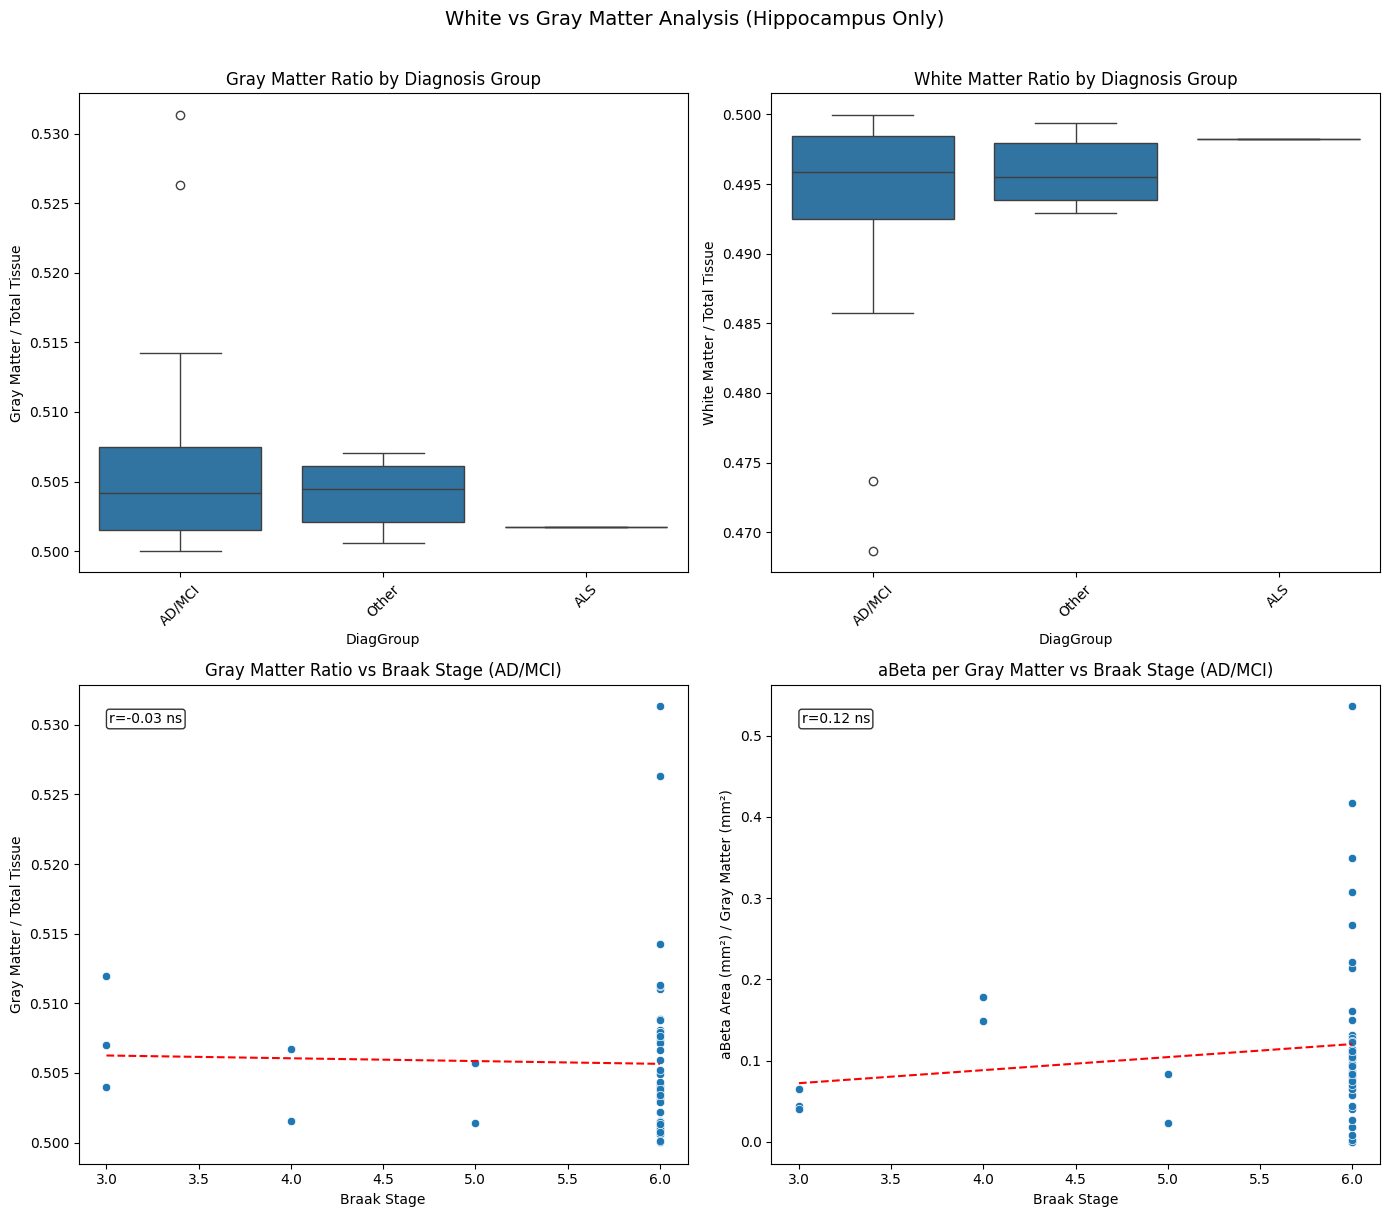

Saved → /nashome/bhavesh/ABeta/aBeta-WSI-Analysi-Pipeline/output/white_gray_matter_analysis.png

Segmentation method counts:
segmentation_method
heuristic_fallback    62
Name: count, dtype: int64

Gray/White Matter Ratios by Diagnosis Group:
          gray_matter_ratio               white_matter_ratio              
                       mean median    std               mean median    std
DiagGroup                                                                 
AD/MCI                0.506  0.504  0.006              0.494  0.496  0.006
ALS                   0.502  0.502    NaN              0.498  0.498    NaN
Other                 0.504  0.504  0.003              0.496  0.496  0.003

Correlation with Braak Stage (AD/MCI only):
  gray_matter_ratio: r=-0.075, p=0.6028 ns
  white_matter_ratio: r=0.075, p=0.6028 ns
  abeta_per_gray_matter: r=0.135, p=0.3489 ns
  abeta_per_white_matter: r=0.131, p=0.3631 ns


In [51]:
# ── Cell 13: White vs Gray Matter Area Analysis ───────────────────────────────
# Compare white vs gray matter area normalized over total tissue area.
# Expect gray matter decrease based on disease severity.

seg_merged = merged_seg[merged_seg["gray_matter_ratio"].notna()].copy()
if seg_merged.empty:
    raise ValueError("No segmentation results available. Run the segmentation cells first.")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

sns.boxplot(data=seg_merged, x="DiagGroup", y="gray_matter_ratio", ax=axes[0, 0])
axes[0, 0].set_title("Gray Matter Ratio by Diagnosis Group")
axes[0, 0].set_ylabel("Gray Matter / Total Tissue")
axes[0, 0].tick_params(axis="x", rotation=45)

sns.boxplot(data=seg_merged, x="DiagGroup", y="white_matter_ratio", ax=axes[0, 1])
axes[0, 1].set_title("White Matter Ratio by Diagnosis Group")
axes[0, 1].set_ylabel("White Matter / Total Tissue")
axes[0, 1].tick_params(axis="x", rotation=45)

ad_mci_seg = seg_merged[seg_merged["DiagGroup"] == "AD/MCI"].copy()
if len(ad_mci_seg) > 0:
    sns.scatterplot(
        data=ad_mci_seg, x="Braak_num", y="gray_matter_ratio", ax=axes[1, 0]
    )
    axes[1, 0].set_title("Gray Matter Ratio vs Braak Stage (AD/MCI)")
    axes[1, 0].set_xlabel("Braak Stage")
    axes[1, 0].set_ylabel("Gray Matter / Total Tissue")

    valid = ad_mci_seg[["Braak_num", "gray_matter_ratio"]].dropna()
    if len(valid) >= 5:
        xs = valid["Braak_num"].values
        ys = valid["gray_matter_ratio"].values
        m, b, r, p, _ = stats.linregress(xs, ys)
        xl = np.linspace(xs.min(), xs.max(), 100)
        axes[1, 0].plot(xl, m * xl + b, "r--", linewidth=1.5)
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
        axes[1, 0].annotate(
            f"r={r:.2f} {sig}",
            xy=(0.05, 0.92),
            xycoords="axes fraction",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8),
        )

    sns.scatterplot(
        data=ad_mci_seg,
        x="Braak_num",
        y="abeta_per_gray_matter",
        ax=axes[1, 1],
    )
    axes[1, 1].set_title("aBeta per Gray Matter vs Braak Stage (AD/MCI)")
    axes[1, 1].set_xlabel("Braak Stage")
    axes[1, 1].set_ylabel("aBeta Area (mm²) / Gray Matter (mm²)")

    valid = ad_mci_seg[["Braak_num", "abeta_per_gray_matter"]].dropna()
    if len(valid) >= 5:
        xs = valid["Braak_num"].values
        ys = valid["abeta_per_gray_matter"].values
        m, b, r, p, _ = stats.linregress(xs, ys)
        xl = np.linspace(xs.min(), xs.max(), 100)
        axes[1, 1].plot(xl, m * xl + b, "r--", linewidth=1.5)
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
        axes[1, 1].annotate(
            f"r={r:.2f} {sig}",
            xy=(0.05, 0.92),
            xycoords="axes fraction",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8),
        )

plt.suptitle("White vs Gray Matter Analysis (Hippocampus Only)", fontsize=14, y=1.01)
plt.tight_layout()
out = OUTPUT_DIR / "white_gray_matter_analysis.png"
plt.savefig(str(out), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out}")

print("\nSegmentation method counts:")
print(seg_merged["segmentation_method"].value_counts(dropna=False))

print("\nGray/White Matter Ratios by Diagnosis Group:")
print(
    seg_merged.groupby("DiagGroup")[["gray_matter_ratio", "white_matter_ratio"]]
    .agg(["mean", "median", "std"])
    .round(3)
)

print("\nCorrelation with Braak Stage (AD/MCI only):")
if len(ad_mci_seg) > 0:
    for var in [
        "gray_matter_ratio",
        "white_matter_ratio",
        "abeta_per_gray_matter",
        "abeta_per_white_matter",
    ]:
        valid = ad_mci_seg[["Braak_num", var]].dropna()
        if len(valid) >= 5:
            r, p = spearmanr(valid["Braak_num"], valid[var])
            sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
            print(f"  {var}: r={r:.3f}, p={p:.4f} {sig}")


In [52]:
# ── Cell 10: Spearman correlation — aBeta burden vs neuropath & clinical (hippocampus only) ───
X_VARS_QUANT = [
    "plaque_count",
    "log_plaque_count",
    "mean_area_mm2",
    "log_mean_area",
    "total_area_mm2",
    "log_total_area",
    "norm_burden_mm2",
    "mean_elongation",
    "mean_eccentricity",
]
Y_VARS = [
    "Braak_num",
    "CERAD_num",
    "Thal_num",
    "ABC_num",
    "Age_onset",
    "Age_death",
    "Duration",
]


def corr_table(df, x_vars, y_vars, label):
    rows = []
    for x in x_vars:
        for y in y_vars:
            sub = df[[x, y]].dropna()
            if len(sub) < 10:
                continue
            r, p = spearmanr(sub[x], sub[y])
            sig = (
                "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
            )
            rows.append(
                {
                    "X Variable": x,
                    "Y Variable": y,
                    "Group": label,
                    "N": len(sub),
                    "Spearman r": round(r, 3),
                    "p-value": round(p, 4),
                    "Significance": sig,
                }
            )
    return pd.DataFrame(rows)


ad_mci = merged[(merged["DiagGroup"] == "AD/MCI") & quant_avail].copy()
all_q = merged[quant_avail].copy()

corr_all_q = corr_table(all_q, X_VARS_QUANT, Y_VARS, "All w/ hippocampus quant")
corr_ad_q = corr_table(ad_mci, X_VARS_QUANT, Y_VARS, "AD/MCI only (hippocampus)")
corr_quant = pd.concat([corr_all_q, corr_ad_q], ignore_index=True)

print(f"Significant correlations (p<0.05):")
sig_df = corr_quant[corr_quant["Significance"] != "ns"]
print(
    sig_df[
        ["X Variable", "Y Variable", "Group", "N", "Spearman r", "Significance"]
    ].to_string(index=False)
)

corr_quant.to_pickle(str(WORK_DIR / "fig4_quant_correlations_hippocampus.pkl"))

Significant correlations (p<0.05):
       X Variable Y Variable                    Group  N  Spearman r Significance
    mean_area_mm2  Age_death All w/ hippocampus quant 62      -0.312            *
    log_mean_area  Age_death All w/ hippocampus quant 62      -0.312            *
  mean_elongation  CERAD_num All w/ hippocampus quant 62       0.251            *
  mean_elongation   Thal_num All w/ hippocampus quant 62       0.309            *
mean_eccentricity  CERAD_num All w/ hippocampus quant 62      -0.253            *


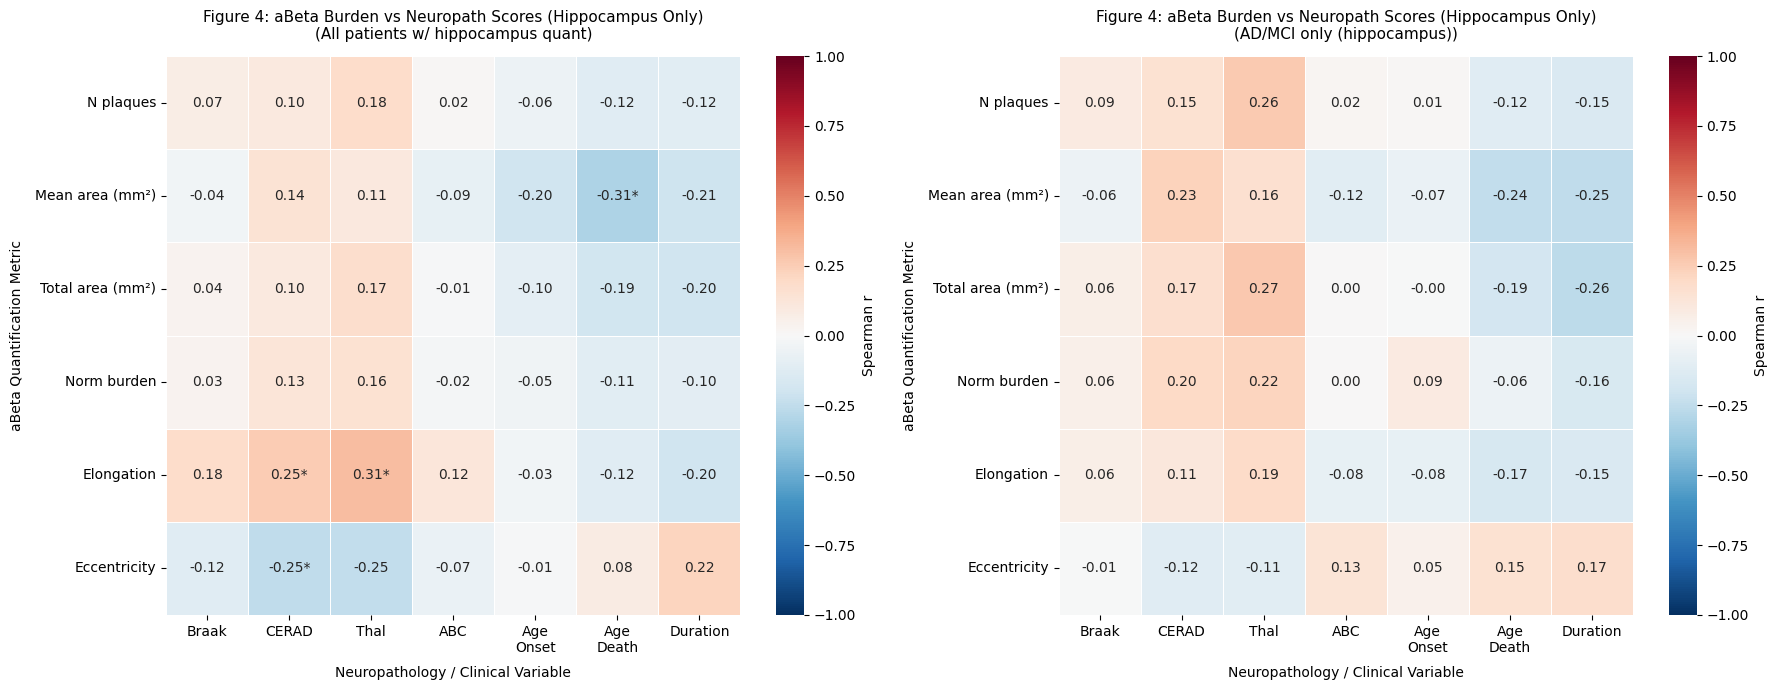

Saved → /nashome/bhavesh/ABeta/aBeta-WSI-Analysi-Pipeline/output/fig4_abeta_correlation_heatmap_hippocampus.png


In [53]:
# ── Cell 11: Figure 4 — Correlation Heatmap (hippocampus only) ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, (group_label, sub_df) in zip(
    axes,
    [
        ("All patients w/ hippocampus quant", all_q),
        ("AD/MCI only (hippocampus)", ad_mci),
    ],
):
    # Build r-matrix
    quant_feats = [
        "plaque_count",
        "mean_area_mm2",
        "total_area_mm2",
        "norm_burden_mm2",
        "mean_elongation",
        "mean_eccentricity",
    ]
    neuropath = [
        "Braak_num",
        "CERAD_num",
        "Thal_num",
        "ABC_num",
        "Age_onset",
        "Age_death",
        "Duration",
    ]

    r_mat = pd.DataFrame(index=quant_feats, columns=neuropath, dtype=float)
    p_mat = pd.DataFrame(index=quant_feats, columns=neuropath, dtype=float)

    for xf in quant_feats:
        for yf in neuropath:
            tmp = sub_df[[xf, yf]].dropna()
            if len(tmp) >= 8:
                r, p = spearmanr(tmp[xf], tmp[yf])
                r_mat.loc[xf, yf] = r
                p_mat.loc[xf, yf] = p

    r_mat = r_mat.astype(float)
    p_mat = p_mat.astype(float)

    # Build annotation matrix
    annot = r_mat.copy().astype(str)
    for i in r_mat.index:
        for j in r_mat.columns:
            rv, pv = r_mat.loc[i, j], p_mat.loc[i, j]
            if pd.isna(rv):
                annot.loc[i, j] = ""
            else:
                stars = (
                    "***"
                    if pv < 0.001
                    else "**" if pv < 0.01 else "*" if pv < 0.05 else ""
                )
                annot.loc[i, j] = f"{rv:.2f}{stars}"

    sns.heatmap(
        r_mat,
        annot=annot,
        fmt="",
        vmin=-1,
        vmax=1,
        cmap="RdBu_r",
        center=0,
        linewidths=0.5,
        xticklabels=[
            "Braak",
            "CERAD",
            "Thal",
            "ABC",
            "Age\nOnset",
            "Age\nDeath",
            "Duration",
        ],
        yticklabels=[
            "N plaques",
            "Mean area (mm²)",
            "Total area (mm²)",
            "Norm burden",
            "Elongation",
            "Eccentricity",
        ],
        ax=ax,
        cbar_kws={"label": "Spearman r"},
    )
    ax.set_title(
        f"Figure 4: aBeta Burden vs Neuropath Scores (Hippocampus Only)\n({group_label})",
        fontsize=11,
        pad=12,
    )
    ax.set_xlabel("Neuropathology / Clinical Variable", labelpad=8)
    ax.set_ylabel("aBeta Quantification Metric", labelpad=8)

plt.tight_layout()
out = OUTPUT_DIR / "fig4_abeta_correlation_heatmap_hippocampus.png"
plt.savefig(str(out), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out}")

htoh, for one wsi, no of plaque

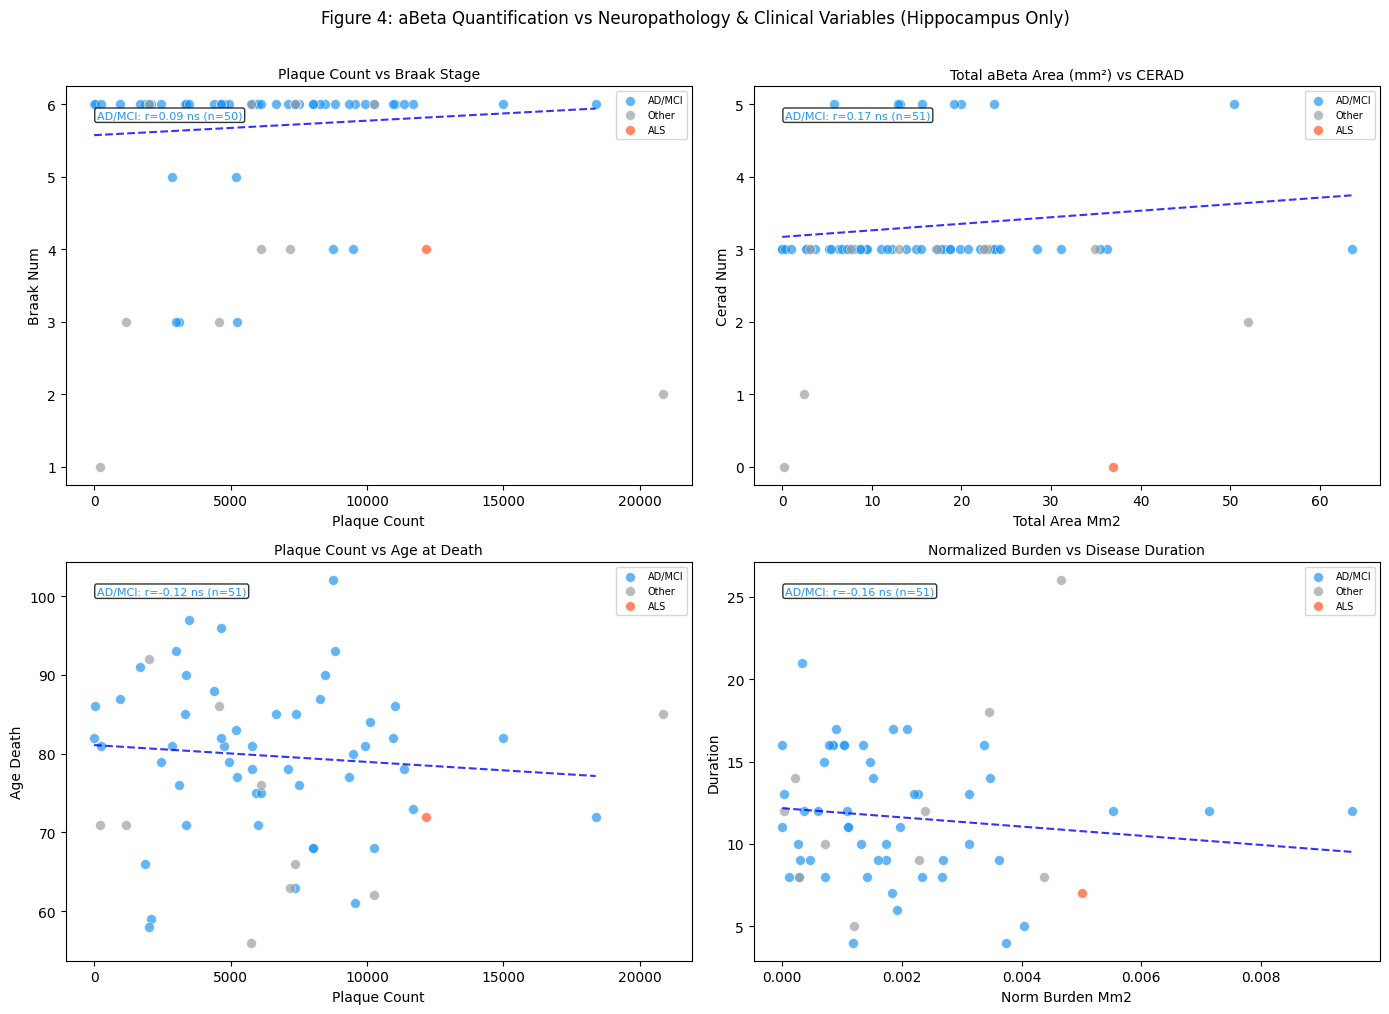

Saved → /nashome/bhavesh/ABeta/aBeta-WSI-Analysi-Pipeline/output/fig4_scatter_plots_hippocampus.png


In [54]:
# ── Cell 12: Figure 4 — Key scatter plots (hippocampus only) ─────────────────────────────────
key_pairs = [
    ("plaque_count", "Braak_num", "Plaque Count vs Braak Stage"),
    ("total_area_mm2", "CERAD_num", "Total aBeta Area (mm²) vs CERAD"),
    ("plaque_count", "Age_death", "Plaque Count vs Age at Death"),
    ("norm_burden_mm2", "Duration", "Normalized Burden vs Disease Duration"),
]

group_colors = {
    "AD/MCI": "#2196F3",
    "LBD": "#4CAF50",
    "ALS": "#FF5722",
    "FTLD-TDP": "#9C27B0",
    "Control": "#607D8B",
    "Other": "#9E9E9E",
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (x, y, title) in zip(axes.flat, key_pairs):
    sub = merged[[x, y, "DiagGroup"]].dropna()
    for grp in sub["DiagGroup"].unique():
        gdf = sub[sub["DiagGroup"] == grp]
        ax.scatter(
            gdf[x],
            gdf[y],
            color=group_colors.get(grp, "#9E9E9E"),
            label=grp,
            alpha=0.7,
            s=50,
            edgecolors="white",
            linewidths=0.5,
        )
    # Regression line for AD/MCI
    ad_sub = sub[sub["DiagGroup"] == "AD/MCI"]
    if len(ad_sub) >= 5:
        xs = ad_sub[x].values.astype(float)
        ys = ad_sub[y].values.astype(float)
        m, b, r, p, _ = stats.linregress(xs, ys)
        xl = np.linspace(xs.min(), xs.max(), 100)
        ax.plot(xl, m * xl + b, "b--", linewidth=1.5, alpha=0.8)
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
        r_sp, p_sp = spearmanr(xs, ys)
        ax.annotate(
            f"AD/MCI: r={r_sp:.2f} {sig} (n={len(ad_sub)})",
            xy=(0.05, 0.92),
            xycoords="axes fraction",
            fontsize=8,
            color="#2196F3",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8),
        )
    ax.set_xlabel(x.replace("_", " ").title())
    ax.set_ylabel(y.replace("_", " ").title())
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=7, loc="upper right")

plt.suptitle(
    "Figure 4: aBeta Quantification vs Neuropathology & Clinical Variables (Hippocampus Only)",
    fontsize=12,
    y=1.01,
)
plt.tight_layout()
out2 = OUTPUT_DIR / "fig4_scatter_plots_hippocampus.png"
plt.savefig(str(out2), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out2}")

### 6. Figure 5 — Clustering with aBeta Quantification

In [55]:
# ── Cell 13: Add aBeta quantification to feature vector and re-cluster ─────
# Use patients that have both neuropath scores AND aBeta quantification
feat_cols_base = [
    "Braak_num",
    "CERAD_num",
    "Thal_num",
    "ABC_num",
    "ApoE_e4dose",
    "TDP_bin",
    "tau_bin",
    "LBD_bin",
    "Vasc_bin",
]
feat_cols_quant = feat_cols_base + [
    "log_plaque_count",
    "log_mean_area",
    "log_total_area",
    "mean_elongation",
    "mean_eccentricity",
]

merged_q = merged[merged["plaque_count"].notna()].copy()

X_full = merged_q[feat_cols_quant].copy()
for col in feat_cols_quant:
    X_full[col] = X_full[col].fillna(X_full[col].median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

from sklearn.metrics import silhouette_score

print("Silhouette scores (with aBeta quantification):")
for k in range(2, 7):
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"  k={k}: silhouette = {score:.4f}")

# Best k=2 (or update if better k found above)
BEST_K = 2
km_best = KMeans(n_clusters=BEST_K, n_init=20, random_state=42)
merged_q["Cluster_Quant"] = km_best.fit_predict(X_scaled)

pca2 = PCA(n_components=2, random_state=42)
pcs = pca2.fit_transform(X_scaled)
merged_q["PCA_Q1"] = pcs[:, 0]
merged_q["PCA_Q2"] = pcs[:, 1]
print(
    f"\nPCA (with quant) variance: PC1={pca2.explained_variance_ratio_[0]*100:.1f}%, "
    f"PC2={pca2.explained_variance_ratio_[1]*100:.1f}%"
)

Silhouette scores (with aBeta quantification):
  k=2: silhouette = 0.4069
  k=3: silhouette = 0.2513
  k=4: silhouette = 0.1445
  k=5: silhouette = 0.1473
  k=6: silhouette = 0.1495

PCA (with quant) variance: PC1=31.2%, PC2=16.5%


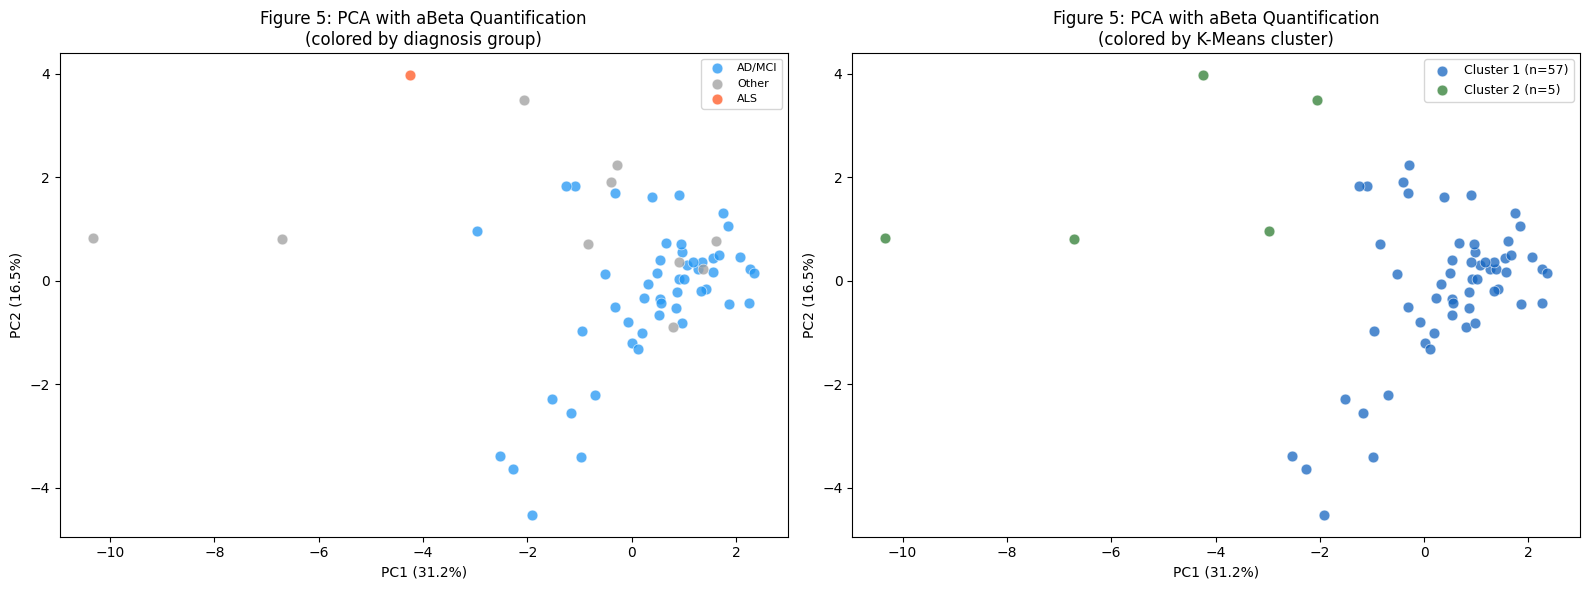

Saved → /nashome/bhavesh/ABeta/aBeta-WSI-Analysi-Pipeline/output/fig5_pca_with_quant.png


In [56]:
# ── Cell 14: Figure 5 — PCA scatter with aBeta quantification ─────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: colored by diagnosis group
for grp in merged_q["DiagGroup"].unique():
    sub = merged_q[merged_q["DiagGroup"] == grp]
    axes[0].scatter(
        sub["PCA_Q1"],
        sub["PCA_Q2"],
        color=group_colors.get(grp, "#9E9E9E"),
        label=grp,
        alpha=0.75,
        s=60,
        edgecolors="white",
        linewidths=0.5,
    )
axes[0].set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].set_title(
    "Figure 5: PCA with aBeta Quantification\n(colored by diagnosis group)"
)
axes[0].legend(fontsize=8, loc="best")

# Right: colored by cluster (K-Means)
clust_colors = {0: "#1565C0", 1: "#2E7D32", 2: "#C62828", 3: "#6A1B9A"}
for c in merged_q["Cluster_Quant"].unique():
    sub = merged_q[merged_q["Cluster_Quant"] == c]
    axes[1].scatter(
        sub["PCA_Q1"],
        sub["PCA_Q2"],
        color=clust_colors.get(c, "grey"),
        label=f"Cluster {c+1} (n={len(sub)})",
        alpha=0.75,
        s=60,
        edgecolors="white",
        linewidths=0.5,
    )
axes[1].set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].set_title(
    "Figure 5: PCA with aBeta Quantification\n(colored by K-Means cluster)"
)
axes[1].legend(fontsize=9)

plt.tight_layout()
out3 = OUTPUT_DIR / "fig5_pca_with_quant.png"
plt.savefig(str(out3), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out3}")

### 7. Cross-Group Comparison — aBeta Burden by Disease Group

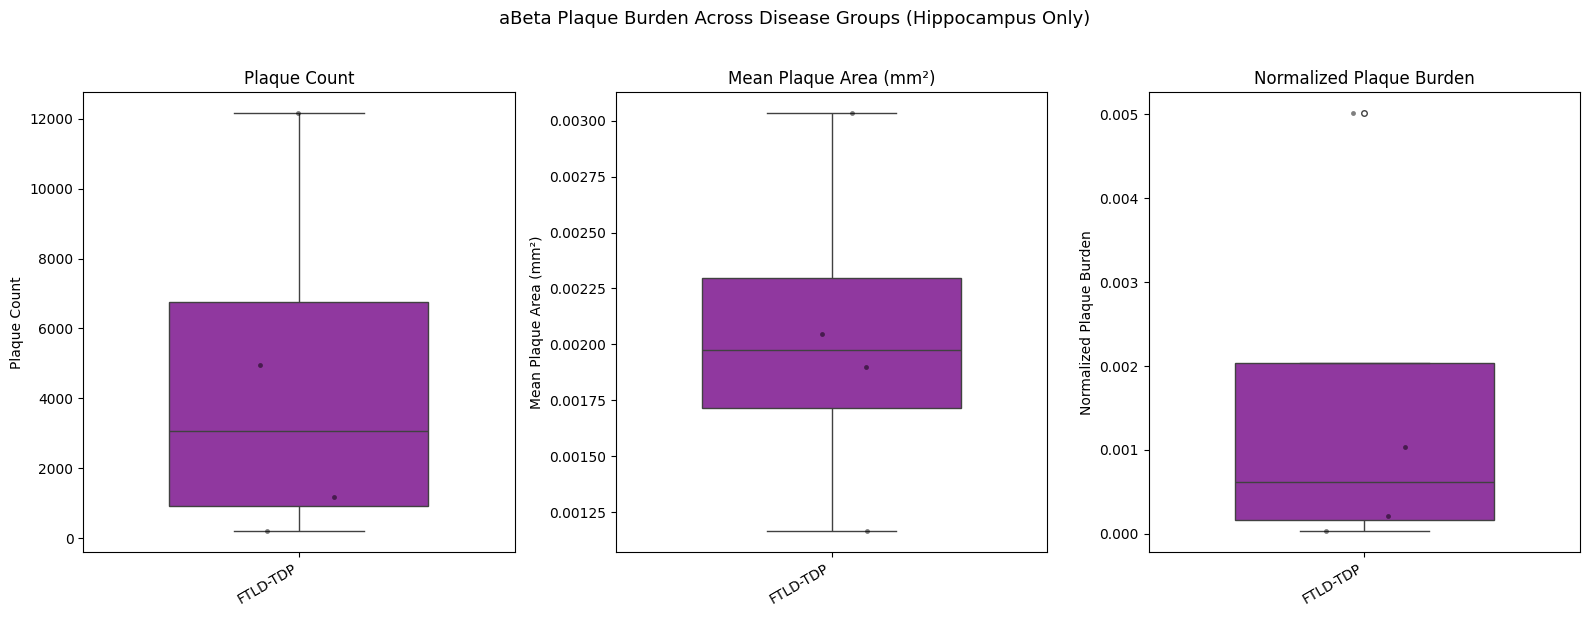

Saved → /nashome/bhavesh/ABeta/aBeta-WSI-Analysi-Pipeline/output/abeta_burden_by_group.png


In [57]:
# ── Cell 15: aBeta burden across all disease groups ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
metrics_to_plot = [
    ("plaque_count", "Plaque Count"),
    ("mean_area_mm2", "Mean Plaque Area (mm²)"),
    ("norm_burden_mm2", "Normalized Plaque Burden"),
]

group_order = ["AD/MCI", "LBD", "LATE-NC", "FTLD-TDP", "ALS", "Control", "Other"]
group_order = [g for g in group_order if g in patient_metrics["group"].unique()]

for ax, (metric, label) in zip(axes, metrics_to_plot):
    plot_df = patient_metrics[patient_metrics["group"].isin(group_order)].copy()
    sns.boxplot(
        data=plot_df,
        x="group",
        y=metric,
        order=group_order,
        palette={g: group_colors.get(g, "#9E9E9E") for g in group_order},
        ax=ax,
        width=0.6,
        fliersize=4,
    )
    sns.stripplot(
        data=plot_df,
        x="group",
        y=metric,
        order=group_order,
        ax=ax,
        size=3.5,
        alpha=0.5,
        color="black",
        jitter=True,
    )
    ax.set_xlabel("")
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")

    groups_data = [
        plot_df[plot_df["group"] == g][metric].dropna().values
        for g in group_order
        if len(plot_df[plot_df["group"] == g]) >= 3
    ]
    if len(groups_data) >= 2:
        stat, p = kruskal(*groups_data)
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
        ax.set_title(f"{label}\nKruskal-Wallis: H={stat:.1f} {sig}", fontsize=9)

plt.suptitle("aBeta Plaque Burden Across Disease Groups (Hippocampus Only)", fontsize=13, y=1.02)
plt.tight_layout()
out4 = OUTPUT_DIR / "abeta_burden_by_group.png"
plt.savefig(str(out4), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out4}")


In [58]:
# ── Cell 16: Pairwise Mann-Whitney AD vs each other group ─────────────────
print("Pairwise Mann-Whitney: AD/MCI vs other groups (plaque_count)")
print("=" * 55)
ad_vals = patient_metrics[patient_metrics["group"] == "AD/MCI"]["plaque_count"].dropna()
for g in [g for g in group_order if g != "AD/MCI"]:
    other = patient_metrics[patient_metrics["group"] == g]["plaque_count"].dropna()
    if len(other) < 3:
        continue
    stat, p = mannwhitneyu(ad_vals, other, alternative="greater")
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    print(
        f"  AD/MCI (n={len(ad_vals)}) vs {g:12s} (n={len(other):2d}):  U={stat:.0f}  p={p:.4f}  {sig}"
    )

Pairwise Mann-Whitney: AD/MCI vs other groups (plaque_count)
  AD/MCI (n=0) vs FTLD-TDP     (n= 4):  U=nan  p=nan  ns


### 8. Save Final Results to Excel

In [59]:
# ── Cell 17: Save all quantification results to Excel ─────────────────────
with pd.ExcelWriter(
    str(WORK_DIR / "abeta_quantification_results.xlsx"), engine="openpyxl"
) as writer:
    manifest.to_excel(writer, sheet_name="Slide_Manifest", index=False)
    hippocampus_manifest.to_excel(writer, sheet_name="Hippocampus_Manifest", index=False)
    slide_metrics.to_excel(writer, sheet_name="Hippocampus_Slide_Metrics", index=False)
    patient_metrics.to_excel(writer, sheet_name="Hippocampus_Patient_Metrics", index=False)
    segmentation_df.to_excel(writer, sheet_name="Hippocampus_Segmentation", index=False)
    patient_metrics_with_seg.to_excel(
        writer, sheet_name="Patient_Metrics_With_Seg", index=False
    )
    corr_quant.to_excel(writer, sheet_name="Fig4_Quant_Correlations", index=False)

    cols_to_save = [
        "np_clinical.Case Number",
        "DiagGroup",
        "Braak_num",
        "CERAD_num",
        "Thal_num",
        "ABC_num",
        "ApoE_e4dose",
        "TDP_bin",
        "tau_bin",
        "LBD_bin",
        "Vasc_bin",
        "Age_onset",
        "Age_death",
        "Duration",
        "group",
        "region",
        "plaque_count",
        "tissue_area_mm2",
        "total_area_mm2",
        "mean_area_mm2",
        "median_area_mm2",
        "area_p90_mm2",
        "norm_burden_mm2",
        "mean_elongation",
        "mean_eccentricity",
        "mean_major_axis_um",
        "gray_matter_area_mm2",
        "white_matter_area_mm2",
        "gray_matter_ratio",
        "white_matter_ratio",
        "abeta_per_gray_matter",
        "abeta_per_white_matter",
        "segmentation_method",
        "Cluster_KMeans",
        "PCA_1",
        "PCA_2",
    ]
    save_cols = [c for c in cols_to_save if c in merged.columns]
    save_cols_seg = [c for c in cols_to_save if c in merged_seg.columns]
    merged[save_cols].to_excel(writer, sheet_name="Merged_Hippocampus", index=False)
    merged_seg[save_cols_seg].to_excel(
        writer, sheet_name="Merged_Hippocampus_Seg", index=False
    )

print("Saved: abeta_quantification_results.xlsx")
print(
    "Sheets: Slide_Manifest | Hippocampus_Manifest | Hippocampus_Slide_Metrics | "
    "Hippocampus_Patient_Metrics | Hippocampus_Segmentation | "
    "Patient_Metrics_With_Seg | Fig4_Quant_Correlations | "
    "Merged_Hippocampus | Merged_Hippocampus_Seg"
)


Saved: abeta_quantification_results.xlsx
Sheets: Slide_Manifest | Hippocampus_Manifest | Hippocampus_Slide_Metrics | Hippocampus_Patient_Metrics | Hippocampus_Segmentation | Patient_Metrics_With_Seg | Fig4_Quant_Correlations | Merged_Hippocampus | Merged_Hippocampus_Seg


In [60]:
# ── Cell 18: Final Summary ─────────────────────────────────────────────────

print("═" * 60)
print("  ANALYSIS SUMMARY")
print("═" * 60)
print(f"  Slides in manifest       : {len(manifest)}")
print(f"  SVS files found          : {manifest.found.sum()}")
print(f"  Hippocampus slides kept  : {len(hippocampus_manifest)}")
print(f"  Slides quantified        : {len(slide_metrics)}")
print(f"  Patients quantified      : {len(patient_metrics)}")
print(f"  Slides segmented         : {len(segmentation_df)}")
print()
print("  Outputs created:")
for f in [
    "output/(H5 files per slide)",
    "patient_abeta_metrics_hippocampus.pkl / .csv",
    "patient_abeta_metrics_with_segmentation.pkl / .csv",
    "hippocampus_segmentation.pkl / .csv",
    "merged_patients_hippocampus.pkl",
    "merged_patients_hippocampus_with_seg.pkl",
    "fig4_quant_correlations_hippocampus.pkl",
    "abeta_quantification_results.xlsx",
    "output/white_gray_matter_analysis.png",
    "output/fig4_abeta_correlation_heatmap_hippocampus.png",
    "output/fig4_scatter_plots_hippocampus.png",
    "output/fig5_pca_with_quant.png",
    "output/abeta_burden_by_group.png",
]:
    print(f"    {f}")
print("═" * 60)


════════════════════════════════════════════════════════════
  ANALYSIS SUMMARY
════════════════════════════════════════════════════════════
  Slides in manifest       : 189
  SVS files found          : 103
  Hippocampus slides kept  : 65
  Slides quantified        : 65
  Patients quantified      : 65
  Slides segmented         : 65

  Outputs created:
    output/(H5 files per slide)
    patient_abeta_metrics_hippocampus.pkl / .csv
    patient_abeta_metrics_with_segmentation.pkl / .csv
    hippocampus_segmentation.pkl / .csv
    merged_patients_hippocampus.pkl
    merged_patients_hippocampus_with_seg.pkl
    fig4_quant_correlations_hippocampus.pkl
    abeta_quantification_results.xlsx
    output/white_gray_matter_analysis.png
    output/fig4_abeta_correlation_heatmap_hippocampus.png
    output/fig4_scatter_plots_hippocampus.png
    output/fig5_pca_with_quant.png
    output/abeta_burden_by_group.png
════════════════════════════════════════════════════════════


In [61]:
# === EXPORT TO HTML ===
import subprocess
from pathlib import Path

notebook_path = Path("abeta_analysis-v1.ipynb")
report_html = Path(
    "/nashome/bhavesh/ABeta/aBeta-WSI-Analysi-Pipeline/output/abeta_analysis-v1.html"
)
report_html.parent.mkdir(parents=True, exist_ok=True)

print(f"Exporting {notebook_path} → {report_html}")
res = subprocess.run(
    [
        "jupyter",
        "nbconvert",
        "--to",
        "html",
        "--output",
        report_html.name,
        "--output-dir",
        str(report_html.parent),
        str(notebook_path),
    ],
    capture_output=True,
    text=True,
)

if res.returncode == 0:
    print(f"HTML report saved to: {report_html}")
else:
    print("Export failed")
    print(res.stderr)

Exporting abeta_analysis-v1.ipynb → /nashome/bhavesh/ABeta/aBeta-WSI-Analysi-Pipeline/output/abeta_analysis-v1.html
HTML report saved to: /nashome/bhavesh/ABeta/aBeta-WSI-Analysi-Pipeline/output/abeta_analysis-v1.html
